In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Display settings
pd.set_option("display.max_columns",None)

In [3]:
nav_df = pd.read_csv("../Data/Processed/nav_history_cleaned.csv")
scheme_df = pd.read_csv("../Data/Processed/scheme_performance_cleaned.csv")
benchmark_df = pd.read_csv("../Data/Processed/benchmark_indices_cleaned.csv")
print("NAV Hiatory")
display(nav_df.head())

print("Scheme performance")
display(scheme_df.head())

print("Benchmark Indices")
display(benchmark_df.head())

NAV Hiatory


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


Scheme performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


Benchmark Indices


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
# Convert date column to datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort values
nav_df = nav_df.sort_values(["amfi_code","date"])

#Calculate Daily Returns
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

# Display output
display(nav_df.head(10))

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [5]:
risk_free_rate = 0.065

# Sharp Ratio for each fund
sharpe_df = nav_df.groupby("amfi_code")["daily_return"].agg(["mean","std"]).reset_index()

sharpe_df["sharpe_ratio"] = ((sharpe_df["mean"]*252) - risk_free_rate)/(sharpe_df["std"]*np.sqrt(252))

display(sharpe_df.head)

<bound method NDFrame.head of     amfi_code      mean       std  sharpe_ratio
0      100016  0.000142  0.009164     -0.201517
1      100025  0.000170  0.002460     -0.567095
2      100033  0.001080  0.011929      1.093699
3      101206  0.000852  0.009177      1.027213
4      101207  0.000424  0.016251      0.162661
5      101208  0.000242  0.000319     -0.815567
6      102885  0.000674  0.008086      0.817099
7      102886  0.000110  0.011424     -0.205832
8      102887  0.000645  0.009927      0.619518
9      118632  0.000865  0.008913      1.081659
10     118633  0.000616  0.008817      0.645207
11     118634  0.000707  0.015901      0.448434
12     118635  0.000600  0.008179      0.664857
13     118636  0.000202  0.002511     -0.356630
14     119092  0.000275  0.008788      0.030785
15     119093  0.000330  0.008809      0.129614
16     119094  0.001027  0.012225      0.998231
17     119095  0.000182  0.015790     -0.075974
18     119120  0.000222  0.002499     -0.226575
19     119

In [6]:
# Sortino Ratio
downside_returns = nav_df.copy()
downside_returns["downside"]=downside_returns["daily_return"].apply(lambda x:x if x < 0 else 0)

sortino_df = downside_returns.groupby("amfi_code").agg(
    mean_return=("daily_return","mean"),downside_std=("downside","std")

).reset_index()

sortino_df["sortino_ratio"]=((sortino_df["mean_return"]*252)-risk_free_rate
)/(sortino_df["downside_std"]*np.sqrt(252))

display(sortino_df.head())

,amfi_code,mean_return,downside_std,sortino_ratio
0,100016,0.000142,0.005162,-0.357783
1,100025,0.000170,0.001381,-1.009902
2,100033,0.001080,0.006630,1.967827
3,101206,0.000852,0.004988,1.890048
4,101207,0.000424,0.009254,0.285643


In [7]:
print(nav_df.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


In [8]:
print(nav_df.dtypes)

amfi_code                int64
date            datetime64[ns]
nav                    float64
daily_return           float64
dtype: object


In [9]:
print(benchmark_df.dtypes)

date            object
index_name      object
close_value    float64
dtype: object


In [10]:
print(nav_df["date"].dtype)
print(benchmark_df["date"].dtype)

datetime64[ns]
object


In [11]:
print(benchmark_df["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [12]:
print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [13]:
fund_master_df=pd.read_csv("../Data/Processed/fund_master_cleaned.csv")

In [14]:
print(fund_master_df.columns)
display(fund_master_df.head())

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [15]:
print(fund_master_df["benchmark"].unique())

['NIFTY 100 TRI' 'BSE 250 SmallCap TRI' 'CRISIL Dynamic Gilt Index'
 'NIFTY Midcap 150 TRI' 'CRISIL Short Term Bond Index' 'NIFTY 500 TRI'
 'CRISIL Liquid Fund AI Index' 'NIFTY 50 TRI' 'NIFTY Midcap 50 TRI'
 'NIFTY Large Midcap 250 TRI']


In [16]:
# Map fund benchmark names to benchmark index names

benchmark_map = {
    "NIFTY 50 TRI": "NIFTY50",
    "NIFTY 100 TRI": "NIFTY100",
    "NIFTY 500 TRI": "NIFTY500",
    "NIFTY Midcap 150 TRI": "NIFTY_MIDCAP150",
    "BSE 250 SmallCap TRI": "BSE_SMALLCAP",
    "CRISIL Dynamic Gilt Index": "CRISIL_GILT",
    "CRISIL Liquid Fund AI Index": "CRISIL_LIQUID"
}

fund_master_df["index_name"] = fund_master_df["benchmark"].map(benchmark_map)

print(fund_master_df[["amfi_code", "benchmark", "index_name"]].head())

   amfi_code                  benchmark    index_name
0     119551              NIFTY 100 TRI      NIFTY100
1     119552              NIFTY 100 TRI      NIFTY100
2     119598       BSE 250 SmallCap TRI  BSE_SMALLCAP
3     119599       BSE 250 SmallCap TRI  BSE_SMALLCAP
4     119120  CRISIL Dynamic Gilt Index   CRISIL_GILT


In [ ]:
benchmark_df.groupby(["index_name","date"]).size().sort_values(ascending=False).head(10)

index_name       date      
NIFTY_MIDCAP150  2026-05-29    1
BSE_SMALLCAP     2022-01-03    1
NIFTY_MIDCAP150  2026-05-07    1
                 2026-05-06    1
                 2026-05-05    1
                 2026-05-04    1
                 2026-05-01    1
                 2026-04-30    1
                 2026-04-29    1
                 2026-04-28    1
dtype: int64

In [ ]:
print(nav_df.shape)
print(nav_df[["amfi_code","date"]].drop_duplicates().shape)

(46000, 5)
(46000, 2)


In [ ]:
print(nav_df[nav_df.duplicated(subset=["amfi_code","date"],keep=False)])

Empty DataFrame
Columns: [amfi_code, date, nav, daily_return, index_name]
Index: []


In [ ]:
print(nav_df["index_name"].value_counts())

index_name
NIFTY100           16100
NIFTY_MIDCAP150     6900
BSE_SMALLCAP        6900
NIFTY500            4600
CRISIL_LIQUID       3450
NIFTY50             2300
CRISIL_GILT         2300
Name: count, dtype: int64


In [ ]:
print(nav_df[nav_df["amfi_code"]==100016][["amfi_code","date","index_name"]].head(20))

    amfi_code       date index_name
0      100016 2022-01-03   NIFTY100
1      100016 2022-01-04   NIFTY100
2      100016 2022-01-05   NIFTY100
3      100016 2022-01-06   NIFTY100
4      100016 2022-01-07   NIFTY100
5      100016 2022-01-10   NIFTY100
6      100016 2022-01-11   NIFTY100
7      100016 2022-01-12   NIFTY100
8      100016 2022-01-13   NIFTY100
9      100016 2022-01-14   NIFTY100
10     100016 2022-01-17   NIFTY100
11     100016 2022-01-18   NIFTY100
12     100016 2022-01-19   NIFTY100
13     100016 2022-01-20   NIFTY100
14     100016 2022-01-21   NIFTY100
15     100016 2022-01-24   NIFTY100
16     100016 2022-01-25   NIFTY100
17     100016 2022-01-26   NIFTY100
18     100016 2022-01-27   NIFTY100
19     100016 2022-01-28   NIFTY100


In [ ]:
from scipy.stats import linregress

alpha_beta = []

for amfi_code, group in merged_df.groupby("amfi_code"):

    if len(group) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            group["benchmark_return"],
            group["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": amfi_code,
            "alpha": intercept * 252,
            "beta": slope
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

display(alpha_beta_df.head())
print(alpha_beta_df.shape)

,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


(40, 3)


In [ ]:
print(alpha_beta_df.head())
print(alpha_beta_df.columns)
print(alpha_beta_df.shape)

   amfi_code     alpha      beta
0     100016  0.035008  0.004843
1     100025  0.043330 -0.003422
2     100033  0.268752  0.024097
3     101206  0.214656 -0.000067
4     101207  0.110250 -0.023588
Index(['amfi_code', 'alpha', 'beta'], dtype='object')
(40, 3)


In [ ]:
print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio',
       'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'alpha_y',
       'beta_y'],
      dtype='object')


In [ ]:
scheme_df = scheme_df.drop(columns=["alpha_x", "beta_x"], errors="ignore")

scheme_df = scheme_df.rename(columns={
    "alpha_y": "alpha",
    "beta_y": "beta"
})

display(scheme_df[["amfi_code", "scheme_name", "alpha", "beta"]].head())

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.234544,-0.025189
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.200476,-0.018619
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303145,-0.003508
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.049328,0.010073
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.056061,-0.000351


In [ ]:
benchmark_df["date"]=pd.to_datetime(benchmark_df["date"])

In [ ]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df.sort_values(["index_name", "date"])

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"].pct_change()
)

merged_df = nav_df.merge(
    benchmark_df[["date", "index_name", "benchmark_return"]],
    on=["date", "index_name"],
    how="inner"
)

merged_df = merged_df.dropna(subset=["daily_return", "benchmark_return"])

In [ ]:
print(merged_df.shape)
display(merged_df.head())

(42513, 6)


,amfi_code,date,nav,daily_return,index_name,benchmark_return
1,100016,2022-01-04,515.0971,-0.010306,NIFTY100,-0.013540
2,100016,2022-01-05,521.7239,0.012865,NIFTY100,0.004003
3,100016,2022-01-06,515.7880,-0.011377,NIFTY100,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,NIFTY100,0.006150
5,100016,2022-01-10,510.7136,-0.008639,NIFTY100,-0.008351


In [18]:
import numpy as np

# Sort data
nav_df = nav_df.sort_values(["amfi_code", "date"])

# First and last NAV for each fund
cagr_df = nav_df.groupby("amfi_code").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
).reset_index()

# Number of years
cagr_df["years"] = (
    (cagr_df["end_date"] - cagr_df["start_date"]).dt.days / 365.25
)

# CAGR
cagr_df["cagr_pct"] = (
    ((cagr_df["end_nav"] / cagr_df["start_nav"]) ** (1 / cagr_df["years"]) - 1) * 100
)

# Display
display(cagr_df[["amfi_code", "cagr_pct"]].head())

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [19]:
scheme_df = scheme_df.merge(
    cagr_df[["amfi_code", "cagr_pct"]],
    on="amfi_code",
    how="left"
)

display(scheme_df[["amfi_code", "scheme_name", "cagr_pct"]].head())

,amfi_code,scheme_name,cagr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,25.804686
1,119552,SBI Bluechip Fund - Direct Plan - Growth,21.524236
2,119598,SBI Small Cap Fund - Regular Plan - Growth,32.423536
3,119599,SBI Small Cap Fund - Direct Plan - Growth,2.054485
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.889419


In [21]:
import numpy as np

nav_df = nav_df.sort_values(["amfi_code", "date"])

cagr_df = nav_df.groupby("amfi_code").agg(
    start_date=("date", "first"),
    end_date=("date", "last"),
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
).reset_index()

cagr_df["years"] = (
    cagr_df["end_date"] - cagr_df["start_date"]
).dt.days / 365.25

cagr_df["cagr_pct"] = ((cagr_df["end_nav"] / cagr_df["start_nav"]) ** (1 / cagr_df["years"]) - 1) * 100

display(cagr_df.head())

,amfi_code,start_date,end_date,start_nav,end_nav,years,cagr_pct
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,2.637074
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,4.458210
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,30.123153
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,23.538361
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,7.938765


In [22]:
scheme_df = scheme_df.merge(
    cagr_df[["amfi_code", "cagr_pct"]],
    on="amfi_code",
    how="left"
)

display(
    scheme_df[["amfi_code", "scheme_name", "cagr_pct"]].head()
)

KeyError: "['cagr_pct'] not in index"

In [23]:
print(cagr_df.columns)

Index(['amfi_code', 'start_date', 'end_date', 'start_nav', 'end_nav', 'years',
       'cagr_pct'],
      dtype='object')


In [24]:
print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'cagr_pct_x', 'cagr_pct_y'],
      dtype='object')


In [25]:
scheme_df = scheme_df.drop(columns=["cagr_pct_x"])

scheme_df = scheme_df.rename(columns={
    "cagr_pct_y": "cagr_pct"
})

display(
    scheme_df[["amfi_code", "scheme_name", "cagr_pct"]].head()
)

,amfi_code,scheme_name,cagr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,25.804686
1,119552,SBI Bluechip Fund - Direct Plan - Growth,21.524236
2,119598,SBI Small Cap Fund - Regular Plan - Growth,32.423536
3,119599,SBI Small Cap Fund - Direct Plan - Growth,2.054485
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.889419


In [26]:
risk_free_rate = 0.065  # 6.5%

sharpe_df = nav_df.groupby("amfi_code").agg(
    mean_return=("daily_return", "mean"),
    std_return=("daily_return", "std")
).reset_index()

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["mean_return"] * 252 - risk_free_rate)
    / (sharpe_df["std_return"] * (252 ** 0.5))
)

display(sharpe_df.head())

,amfi_code,mean_return,std_return,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [28]:
print(sharpe_df.columns)

Index(['amfi_code', 'mean_return', 'std_return', 'sharpe_ratio'], dtype='object')


In [29]:
print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'cagr_pct', 'sharpe_ratio_y'],
      dtype='object')


In [30]:
scheme_df = scheme_df.drop(columns=["sharpe_ratio_x"], errors="ignore")

scheme_df = scheme_df.rename(columns={
    "sharpe_ratio_y": "sharpe_ratio"
})

display(
    scheme_df[["amfi_code", "scheme_name", "sharpe_ratio"]].head()
)

,amfi_code,scheme_name,sharpe_ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.953279
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.945308
3,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.057187
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.226575


In [31]:
print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'cagr_pct', 'sharpe_ratio'],
      dtype='object')


In [32]:
scheme_df["score"] = (
    scheme_df["return_3yr_pct"].rank(pct=True) * 30 +
    scheme_df["sharpe_ratio"].rank(pct=True) * 25 +
    scheme_df["alpha"].rank(pct=True) * 20 +
    (1 - scheme_df["expense_ratio_pct"].rank(pct=True)) * 15 +
    (1 - scheme_df["max_drawdown_pct"].rank(pct=True)) * 10
)

display(
    scheme_df[["scheme_name", "score"]]
    .sort_values("score", ascending=False)
    .head(10)
)

,scheme_name,score
22,Kotak Flexicap Fund - Regular - Growth,77.1250
26,Axis Midcap Fund - Regular - Growth,68.6250
12,ICICI Pru Midcap Fund - Regular - Growth,67.8750
34,Mirae Asset Large Cap Fund - Regular - Growth,67.3750
2,SBI Small Cap Fund - Regular Plan - Growth,66.2500
29,ABSL Small Cap Fund - Regular - Growth,65.4375
3,SBI Small Cap Fund - Direct Plan - Growth,64.3125
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,62.8750
38,DSP Midcap Fund - Regular - Growth,62.8750
35,Mirae Asset Emerging Bluechip Fund - Regular -...,62.5625


In [35]:
scheme_df.to_csv("fund_scorecard.csv", index=False)

#alpha_beta_df.to_csv("alpha_beta.csv", index=False)

print("CSV files exported successfully!")

CSV files exported successfully!


In [34]:
scheme_df.to_csv("fund_scorecard.csv", index=False)

scheme_df[["amfi_code", "alpha", "beta"]].to_csv(
    "alpha_beta.csv",
    index=False
)

print("CSV files exported successfully!")

CSV files exported successfully!


In [40]:
scheme_df.to_csv("fund_scorecard.csv", index=False)

#alpha_beta_df.to_csv("alpha_beta.csv", index=False)

print("CSV files exported successfully!")

CSV files exported successfully!


In [39]:
scheme_df[["amfi_code", "alpha", "beta"]].to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv exported successfully!")

alpha_beta.csv exported successfully!


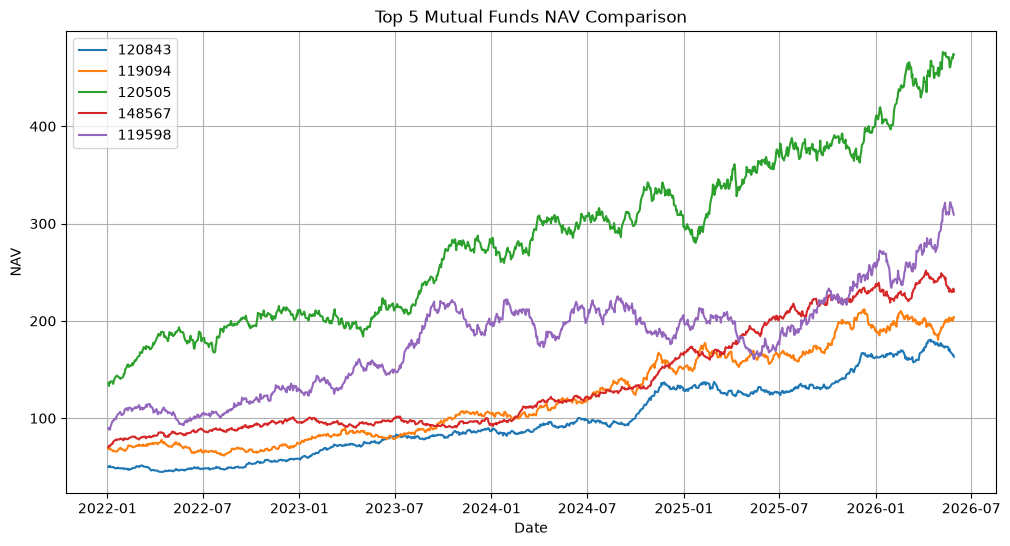

In [42]:
import matplotlib.pyplot as plt

# Top 5 funds by score
top5 = scheme_df.nlargest(5, "score")["amfi_code"]

# NAV data for top 5 funds
top5_nav = nav_df[nav_df["amfi_code"].isin(top5)]

plt.figure(figsize=(12, 6))

# Plot top 5 funds
for code in top5:
    temp = top5_nav[top5_nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=str(code))

plt.title("Top 5 Mutual Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.savefig("benchmark_comparison_chart.png")
plt.show()

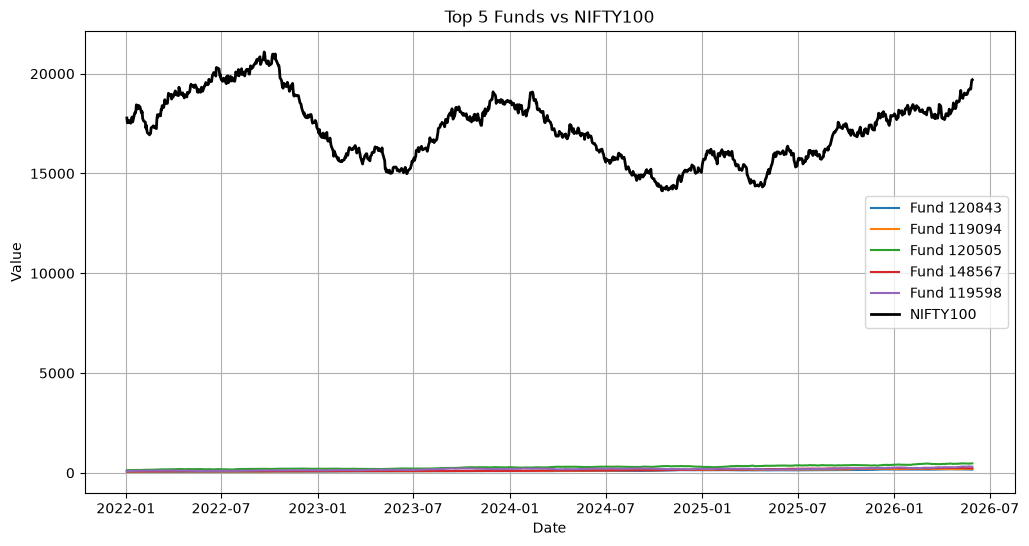

In [45]:
plt.figure(figsize=(12,6))

# Top 5 funds
for code in top5:
    temp = top5_nav[top5_nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=f"Fund {code}")

# Benchmark
nifty = benchmark_df[benchmark_df["index_name"] == "NIFTY100"]
plt.plot(
    nifty["date"],
    nifty["close_value"],
    color="black",
    linewidth=2,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.savefig("benchmark_comparison_chart.png")
plt.show()

In [46]:
top5_nav["date"] = pd.to_datetime(top5_nav["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

C:\Users\HP\AppData\Local\Temp\ipykernel_22572\2902212795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5_nav["date"] = pd.to_datetime(top5_nav["date"])
